# Create dataset and test model on slow fashion data

In [1]:
from pydantic import BaseModel
import re
import pandas as pd
from urllib.parse import unquote

class SlowFashionDto(BaseModel):
    url: str
    id: str
    brand: str
    sex: str
    main: str
    sub: str

with open('data/slowfashion_all_images.txt', 'r') as file:
    lines = file.readlines()

print(lines[0])

def remove_suffixes(filename, suffixes=["-front.png", "-front.jpg", "-back.png", "-back.jpg", "-label.png", "-label.jpg"]):
    for suffix in suffixes:
        if filename.endswith(suffix):
            return filename.removesuffix(suffix)
    return filename

res: list[SlowFashionDto] = []
for line in lines:
    parsing1 = remove_suffixes(line.removeprefix("https://images.slowfashion.se/products/")).split('/')
    parsing2 = re.split(r"[-_]", parsing1[1])
    index = next((i for i, s in enumerate(parsing2) if "fashion" in s), -1)

    if index == -1:
        continue

    res.append(SlowFashionDto(
        url=line.encode("latin1").decode("utf-8"), # change weird characters resulting in 404 (hermÃ¨s -> hermès)
        id=parsing1[0],
        brand=" ".join(parsing2[:index-1]),
        sex=parsing2[index-1],
        main=parsing2[index+1],
        sub=parsing2[index+2]
    ))

df = pd.DataFrame([item.model_dump() for item in res])
df


https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/unknown-womens-fashion-unknown-unknown-unknown-front.png



,url,id,brand,sex,main,sub
0,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,unknown,womens,unknown,unknown
1,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops
2,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high
3,https://images.slowfashion.se/products/cc1fafc...,cc1fafcb-9470-445f-b94a-1e55f84a5a55,saint laurent,womens,shoes,high
4,https://images.slowfashion.se/products/0682634...,06826347-25a3-4393-ba31-4f8ced68bc61,gucci,womens,shoes,sneakers
...,...,...,...,...,...,...
2686,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops
2687,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops
2688,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats
2689,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats


In [2]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np

def get_image(url):
    url = url.strip()
    try:
        response = requests.get(url)
        response.raise_for_status()  # check for HTTP errors
        img = Image.open(BytesIO(response.content))
        # Remove alpha by compositing onto a white background
        img = img.convert("RGBA")
        background = Image.new("RGB", img.size, (255, 255, 255))
        rgb_img = Image.alpha_composite(background.convert("RGBA"), img).convert("RGB")
        resized_imge = rgb_img.resize((224, 224))
        arr = np.array(resized_imge)
        if np.all(arr == 0):
            print(f"Warning: Image at {url} is all black")
            return None 
        return arr
    except Exception as e:
        print(f"Error loading {url}: {e}")
        return None

def load_image(path):
    image = Image.open(path)
    resized_imge = image.resize((224, 224))
    return np.array(resized_imge, )

df['image'] =df['url'].apply(get_image)
df

Error loading https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/unknown-womens-fashion-unknown-unknown-unknown-front.png: 404 Client Error: Not Found for url: https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/unknown-womens-fashion-unknown-unknown-unknown-front.png
Error loading https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/unknown-womens-fashion-unknown-unknown-unknown-label.jpg: 404 Client Error: Not Found for url: https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/unknown-womens-fashion-unknown-unknown-unknown-label.jpg
Error loading https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/acne-studios-womens-fashion-clothing-coats-outerwear-l-first-detail.jpg: 404 Client Error: Not Found for url: https://images.slowfashion.se/products/ca393803-9238-473e-b275-7b70e8c942ec/acne-studios-womens-fashion-clothing-coats-outerwear-l-first-detail.jpg
Error loading ht

,url,id,brand,sex,main,sub,image
0,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,unknown,womens,unknown,unknown,None
1,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,https://images.slowfashion.se/products/cc1fafc...,cc1fafcb-9470-445f-b94a-1e55f84a5a55,saint laurent,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,https://images.slowfashion.se/products/0682634...,06826347-25a3-4393-ba31-4f8ced68bc61,gucci,womens,shoes,sneakers,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
...,...,...,...,...,...,...,...
2686,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[246, 245, 240], [247, 246, 241], [247, 246,..."
2687,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[193, 199, 206], [173, 174, 177], [226, 221,..."
2688,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats,None
2689,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats,None


## Save to csv cause the parsing and get takes a while

In [3]:
df.to_pickle("data/slowfashion.pkl")

## Load the csv

In [4]:
import pandas as pd

df = pd.read_pickle("data/slowfashion.pkl")
df

,url,id,brand,sex,main,sub,image
0,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,unknown,womens,unknown,unknown,None
1,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,https://images.slowfashion.se/products/cc1fafc...,cc1fafcb-9470-445f-b94a-1e55f84a5a55,saint laurent,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,https://images.slowfashion.se/products/0682634...,06826347-25a3-4393-ba31-4f8ced68bc61,gucci,womens,shoes,sneakers,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
...,...,...,...,...,...,...,...
2686,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[246, 245, 240], [247, 246, 241], [247, 246,..."
2687,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[193, 199, 206], [173, 174, 177], [226, 221,..."
2688,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats,None
2689,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats,None


## Data exploration

In [5]:
df["brand"] = df["brand"].replace("unknown", pd.NA)
df["sex"] = df["sex"].replace("unknown", pd.NA)
df["main"] = df["main"].replace("unknown", pd.NA)
df["sub"] = df["sub"].replace("unknown", pd.NA)
df

,url,id,brand,sex,main,sub,image
0,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,<NA>,womens,<NA>,<NA>,None
1,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,https://images.slowfashion.se/products/cc1fafc...,cc1fafcb-9470-445f-b94a-1e55f84a5a55,saint laurent,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,https://images.slowfashion.se/products/0682634...,06826347-25a3-4393-ba31-4f8ced68bc61,gucci,womens,shoes,sneakers,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
...,...,...,...,...,...,...,...
2686,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[246, 245, 240], [247, 246, 241], [247, 246,..."
2687,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[193, 199, 206], [173, 174, 177], [226, 221,..."
2688,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats,None
2689,https://images.slowfashion.se/products/ca39380...,ca393803-9238-473e-b275-7b70e8c942ec,acne studios,womens,clothing,coats,None


In [6]:
print(df["sex"].value_counts())
print()
print(df["main"].value_counts())
print()
print(df["sub"].value_counts())
print()

df.isna().sum()

sex
womens         1629
mens            925
men's           125
women's           9
front.png\n       1
back.png\n        1
label.jpg\n       1
Name: count, dtype: int64

main
clothing       1402
accessories     320
shoes           308
apparel         192
bags            135
jewellery       101
other            62
womens            3
Name: count, dtype: int64

sub
coats          247
shirts         231
dresses        212
jackets        188
ties           167
high           130
tops           119
trousers       119
skirts          95
jeans           94
knitwear        79
suits           66
accessories     62
shoulder        59
hats            47
hair            40
scarves         38
sneakers        32
bracelets       32
sweatshirts     32
briefcases      27
chain           24
belts           23
casual          20
trainers        19
swimwear        19
sunglasses      19
boots           18
oxford          18
wallets         15
athletic        15
loafers         14
lace            13
polo  

url        0
id         0
brand    166
sex        0
main     168
sub      168
image      7
dtype: int64

In [7]:
df = df[~df["main"].isin(["anonymous", "noa", "womens"])].reset_index(drop=True)
df = df[~df["image"].isin([None])].reset_index(drop=True)

In [8]:
df = df.dropna(subset=["main"]).reset_index(drop=True)
df

,url,id,brand,sex,main,sub,image
0,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
1,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,https://images.slowfashion.se/products/cc1fafc...,cc1fafcb-9470-445f-b94a-1e55f84a5a55,saint laurent,womens,shoes,high,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,https://images.slowfashion.se/products/0682634...,06826347-25a3-4393-ba31-4f8ced68bc61,gucci,womens,shoes,sneakers,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,https://images.slowfashion.se/products/4b4ab20...,4b4ab20b-f152-4ce3-b161-a30855aeadc0,gucci,womens,accessories,sunglasses,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
...,...,...,...,...,...,...,...
2510,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[175, 175, 173], [175, 175, 173], [175, 175,..."
2511,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[202, 201, 197], [202, 201, 197], [202, 201,..."
2512,https://images.slowfashion.se/products/f5d6592...,f5d6592a-bccd-4829-9ae7-e5d0300e5f6a,acne studios,womens,shoes,high,"[[[191, 187, 184], [191, 187, 184], [189, 188,..."
2513,https://images.slowfashion.se/products/39ed71d...,39ed71d3-b301-4daa-9a72-0a8dd33257eb,acne studios,womens,clothing,tops,"[[[246, 245, 240], [247, 246, 241], [247, 246,..."


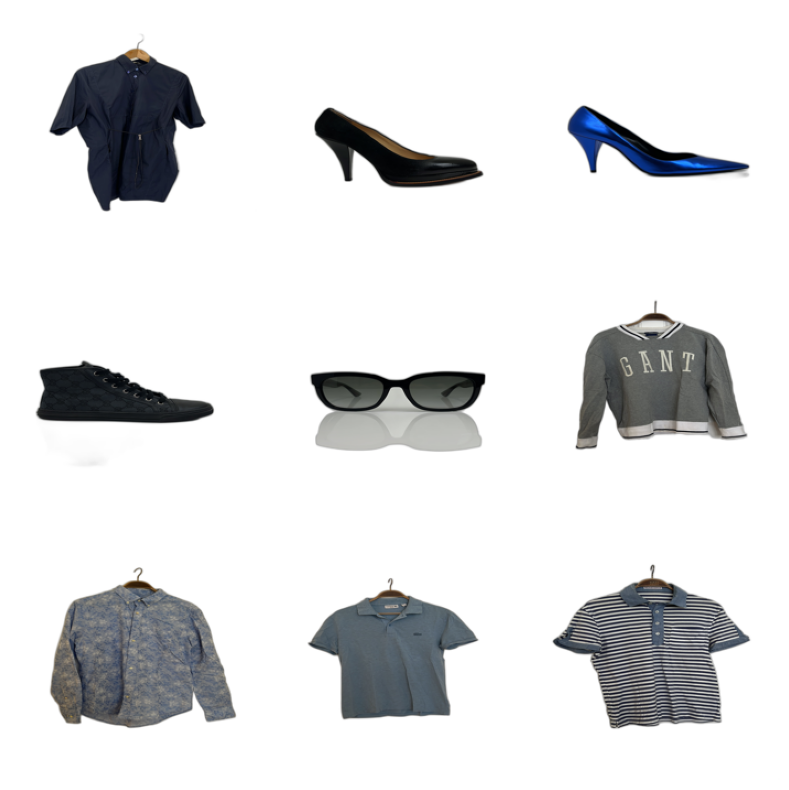

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = df["image"].iloc[i]
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Create the split

In [10]:
X = df['image']
y = df['main']
num_classes = len(df["main"].unique())
print("num_classes:", num_classes)

num_classes: 7


## Get weights

In [13]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [ ]:
from train_model import train_model

## Load the model

In [15]:
import torch
import torch.nn as nn
from torchvision import models

# Recreate the model architecture
model_loaded = models.vgg19(weights=True)

# Freeze weights
for param in model_loaded.features.parameters():
    param.requires_grad = False

# Unfreeze specific layers
for i in [34, 32, 30, 28]:
    for param in model_loaded.features[i].parameters():
        param.requires_grad = True

# Update classifier output for your task
model_loaded.classifier[6] = nn.Linear(4096, num_classes)

# Load the trained weights
# model_loaded.load_state_dict(torch.load('model/vgg19_finetuned.pth'))


## Train the base model